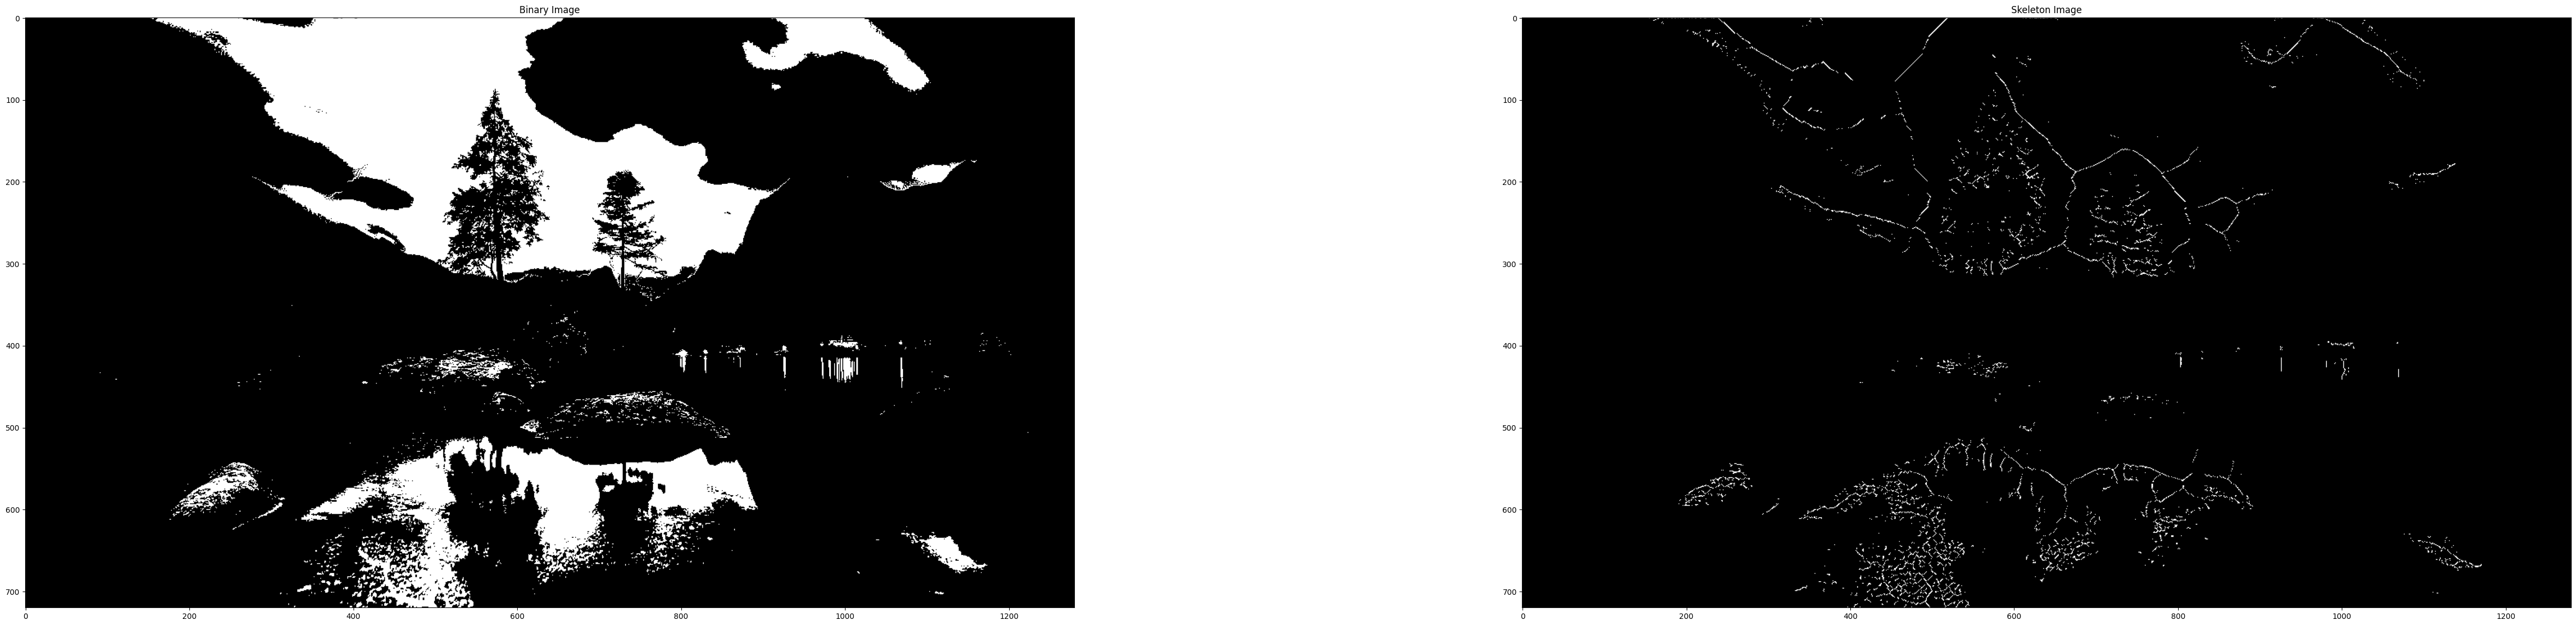

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img=cv2.imread("sample.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
skeleton = np.zeros(binary.shape, np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
temp_img = binary.copy()
while True:
    eroded = cv2.erode(temp_img, kernel)
    opened = cv2.morphologyEx(eroded, cv2.MORPH_OPEN, kernel)
    temp = cv2.subtract(eroded, opened)
    skeleton = cv2.bitwise_or(skeleton, temp)
    temp_img = eroded.copy()
    if cv2.countNonZero(temp_img) == 0:
        break
plt.figure(figsize=(100,14))
plt.subplot(131)
plt.title("Binary Image")
plt.imshow(binary, cmap='gray')
plt.subplot(132)
plt.title("Skeleton Image")
plt.imshow(skeleton, cmap='gray')
plt.show()


Total Components Detected: 1561

Component: 1
Area: 6
Bounding Box: (np.int32(153), np.int32(0), np.int32(4), np.int32(2))

Component: 2
Area: 105209
Bounding Box: (np.int32(159), np.int32(0), np.int32(770), np.int32(326))

Component: 3
Area: 8810
Bounding Box: (np.int32(875), np.int32(0), np.int32(228), np.int32(91))

Component: 4
Area: 1
Bounding Box: (np.int32(927), np.int32(11), np.int32(1), np.int32(1))

Component: 5
Area: 1
Bounding Box: (np.int32(188), np.int32(16), np.int32(1), np.int32(1))

Component: 6
Area: 1
Bounding Box: (np.int32(192), np.int32(16), np.int32(1), np.int32(1))

Component: 7
Area: 3
Bounding Box: (np.int32(1046), np.int32(17), np.int32(2), np.int32(2))

Component: 8
Area: 1
Bounding Box: (np.int32(201), np.int32(21), np.int32(1), np.int32(1))

Component: 9
Area: 1
Bounding Box: (np.int32(205), np.int32(23), np.int32(1), np.int32(1))

Component: 10
Area: 1
Bounding Box: (np.int32(207), np.int32(23), np.int32(1), np.int32(1))

Component: 11
Area: 4
Bounding Bo

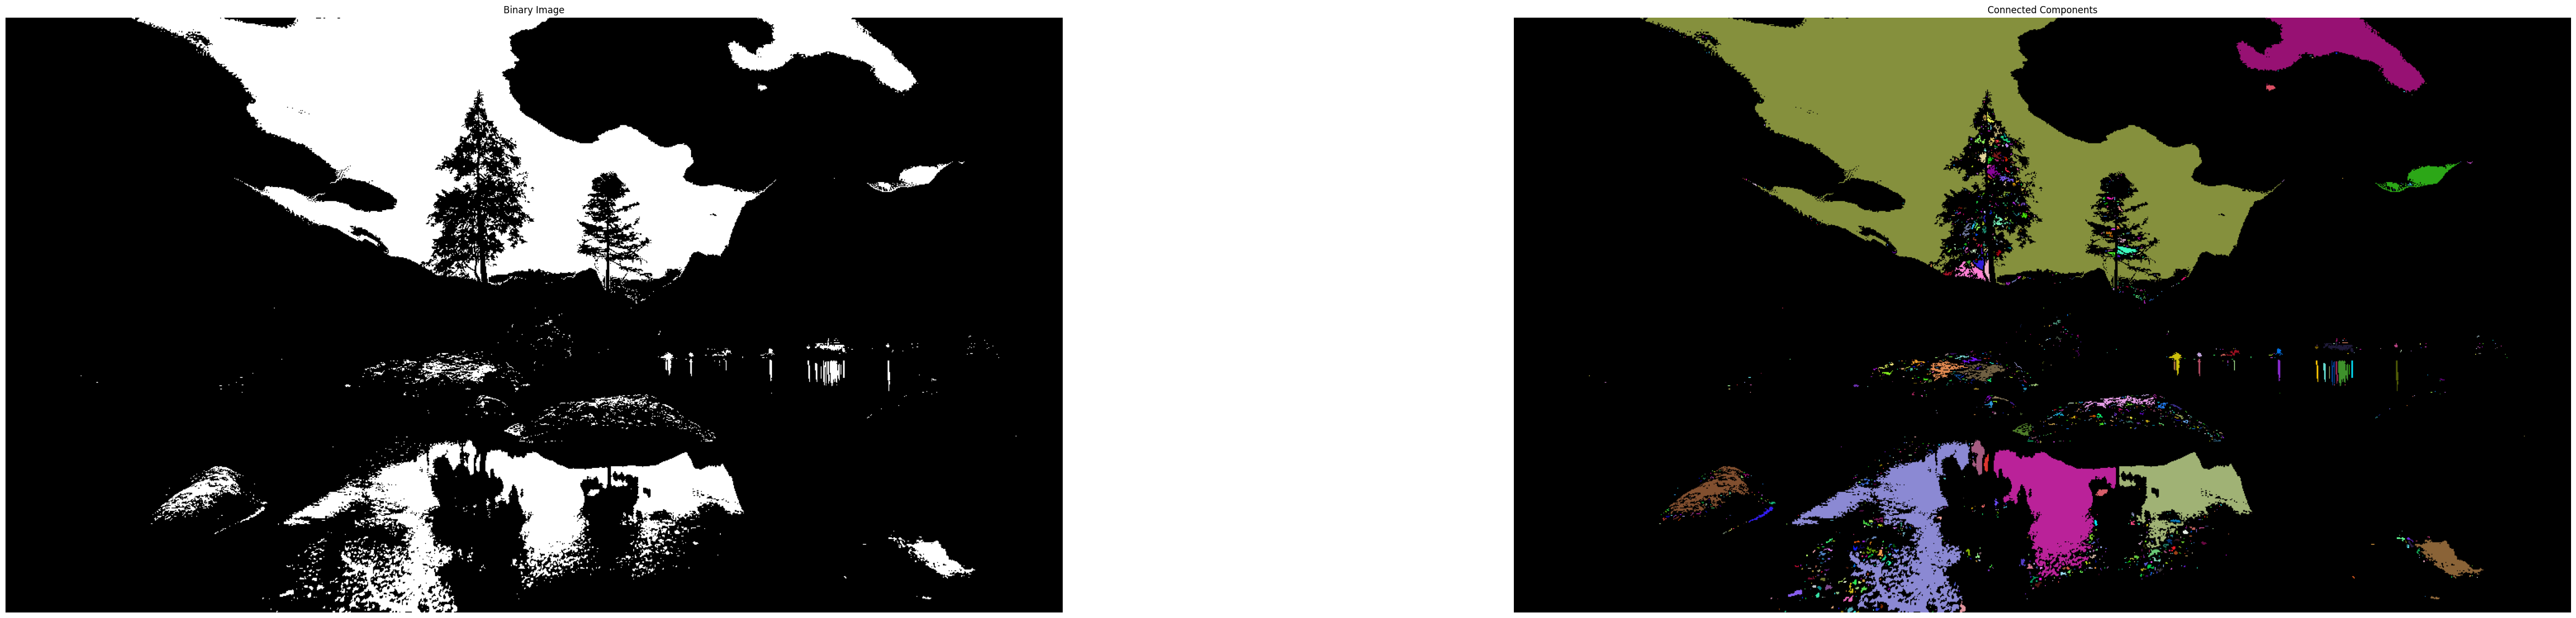

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
print("Total Components Detected:", num_labels-1)
output = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)


for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    print("\nComponent:", i)
    print("Area:", area)
    print("Bounding Box:", (x, y, w, h))
    output[labels == i] = np.random.randint(0,255,3)


plt.figure(figsize=(100,14))
plt.subplot(131)
plt.title("Binary Image")
plt.imshow(binary, cmap='gray')
plt.axis("off")
plt.subplot(132)
plt.title("Connected Components")
plt.imshow(output)
plt.axis("off")
plt.show()


Statistical Features
Mean: 71.64647135416666
Standard Deviation: 49.9797962449583
Variance: 2497.980032687548
Skewness: 0.6636324243891663
Kurtosis: -0.5041705529365865

Histogram Features
Histogram Mean: 3600.0
Histogram Energy: 5532923000.0
Histogram Entropy: -11400142.0

GLCM Features
Contrast: 123.50905003909304
Correlation: 0.9752664064391408
Energy: 0.02052403239467446
Homogeneity: 0.2972282852780133


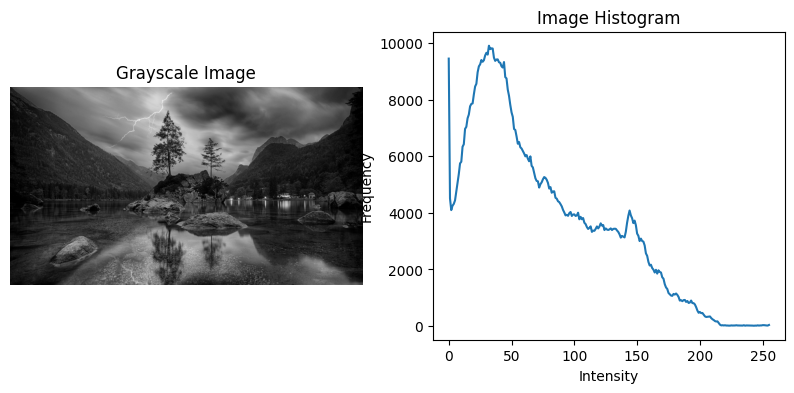

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops


img = cv2.imread("sample.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Image not found")
    exit()


mean_val = np.mean(img)
std_val = np.std(img)
variance_val = np.var(img)
skewness_val = skew(img.flatten())
kurtosis_val = kurtosis(img.flatten())


print("Statistical Features")
print("Mean:", mean_val)
print("Standard Deviation:", std_val)
print("Variance:", variance_val)
print("Skewness:", skewness_val)
print("Kurtosis:", kurtosis_val)


hist = cv2.calcHist([img], [0], None, [256], [0,256])
hist_mean = np.mean(hist)
hist_energy = np.sum(hist**2)
hist_entropy = -np.sum(hist * np.log2(hist + 1))


print("\nHistogram Features")
print("Histogram Mean:", hist_mean)
print("Histogram Energy:", hist_energy)
print("Histogram Entropy:", hist_entropy)


glcm = graycomatrix(img,
                    distances=[1],
                    angles=[0],
                    levels=256,
                    symmetric=True,
                    normed=True)


contrast = graycoprops(glcm, 'contrast')[0,0]
correlation = graycoprops(glcm, 'correlation')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]


print("\nGLCM Features")
print("Contrast:", contrast)
print("Correlation:", correlation)
print("Energy:", energy)
print("Homogeneity:", homogeneity)


plt.figure(figsize=(10,4))


plt.subplot(121)
plt.title("Grayscale Image")
plt.imshow(img, cmap='gray')
plt.axis("off")


plt.subplot(122)
plt.title("Image Histogram")
plt.plot(hist)
plt.xlabel("Intensity")
plt.ylabel("Frequency")


plt.show()


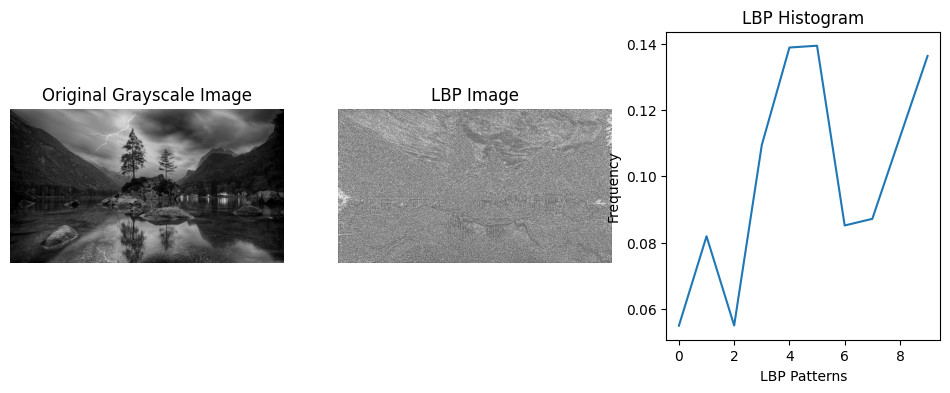

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern


img = cv2.imread("sample.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Image not found")
    exit()
radius = 1
points = 8 * radius
lbp = local_binary_pattern(img, points, radius, method="uniform")
(hist, bins) = np.histogram(lbp.ravel(),
                            bins=np.arange(0, points + 3),
                            range=(0, points + 2))
hist = hist.astype("float")
hist /= hist.sum()


plt.figure(figsize=(12,4))
plt.subplot(131)
plt.title("Original Grayscale Image")
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.subplot(132)
plt.title("LBP Image")
plt.imshow(lbp, cmap='gray')
plt.axis("off")
plt.subplot(133)
plt.title("LBP Histogram")
plt.plot(hist)
plt.xlabel("LBP Patterns")
plt.ylabel("Frequency")
plt.show()
